## First check that we can learn accurately with forward-backward Baum-Welch algorithm (sanity check on my initial design)

code from https://github.com/vicariousinc/naturecomm_cscg/blob/main/chmm_actions.py

In [1]:
## Requirements

## Libs 
import numpy as np
import numpy.random as rd
import scipy as sc
from tqdm import tqdm as tqdm
import seaborn as sns

<Axes: >

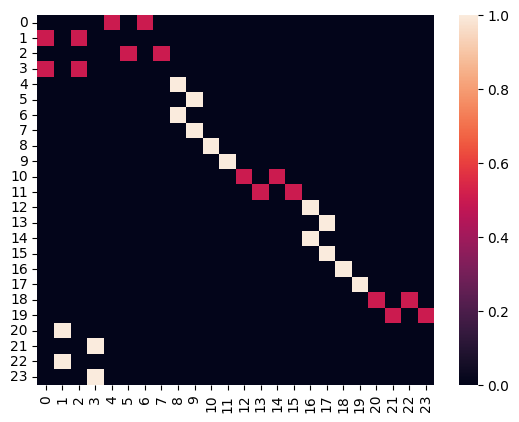

In [2]:
''' Task matrix initialization '''


######## Initialize parameters of the environment --- to include in CHMM class eventually when I make this more generalizable

#Initialize clone number vector
obs = np.arange(0,14,step=1)
n_clones = 2 #Temp TO REMOVE 
n_clones = (np.ones(shape=obs.shape, dtype=np.int64))
n_clones[4:] = n_clones[4:]*2 #Attribute 2 clones to the noisy observations


# Create the latent state labels, clones are next to each other 
latent_labels = []
for z in range(len(obs)):
    for clone in range(n_clones[z]):
        latent_labels.append(z)
latent_labels = np.array(latent_labels)
# Create label matrix 
T_labels = [] ## Shouldn't be necessary in the end        
        
# Example parse to find the appropriate clones
state_loc = np.hstack((np.array([0], dtype=n_clones.dtype), n_clones)).cumsum() # Inds of the first clone of each ensemble
clone_slice = slice(state_loc[5],state_loc[5]+n_clones[5]) 
test1 = latent_labels[clone_slice] #example


def decoder(x,n_clones=n_clones,location_start=state_loc): # give slice coordinates in general coords for the clones mapped to emission x
    #will need extra work for more complex stimulus space than intergers
    clone_slice = slice(location_start[x],location_start[x]+n_clones[x])
    return clone_slice



#####
k = 4 # Number of noise steps 
dim = latent_labels.shape[0]


A = np.zeros(shape=(dim,dim))

# Signal nodes, manual picking
# 0 nodes
A[4,0] = 0.5
A[6,0] = 0.5

A[0,1] = 0.5
A[2,1] = 0.5

A[5,2] = 0.5
A[7,2] = 0.5

A[0,3] = 0.5
A[2,3] = 0.5 


# Noise nodes, sequentially pick MANUAL FOR THE END
progress = 0
for x in range(4,len(n_clones)-2): # need to advance on each step ? or jsut go on n clones and do it in 3 steps is etter
    progress += 1
    if progress%4 == 1 : 
        start = decoder(x) 
        arrival = decoder(x+2)
        A[arrival,start] = np.diag(np.full(2,1))
    elif progress%4 == 2:
        start = decoder(x) 
        arrival = decoder(x+1)
        A[arrival,start] = np.diag(np.full(2,1))
    elif progress%4 == 3:
        start = decoder(x) 
        arrival = decoder(x+1)
        A[arrival,start] = np.diag(np.full(2,1))
    elif progress%4 == 0:
        start = decoder(x) 
        arrival_1 = decoder(x+1)
        arrival_2 = decoder(x+2)
        A[arrival_1,start] = np.diag(np.full(2,0.5))
        A[arrival_2,start] = np.diag(np.full(2,0.5))

# Tail end
x = 12
start = decoder(x) 
A[1,start] = np.array([1,0])
A[3,start] = np.array([0,1])

x = 13
start = decoder(x) 
A[1,start] = np.array([1,0])
A[3,start] = np.array([0,1])

sns.heatmap(A.T)






In [3]:
''' import code '''

import numpy as np
from chmm_actions import CHMM, forwardE, datagen_structured_obs_room
import matplotlib.pyplot as plt
import igraph
from matplotlib import cm, colors
import os

custom_colors = (
    np.array(
        [
            [214, 214, 214],
            [85, 35, 157],
            [253, 252, 144],
            [114, 245, 144],
            [151, 38, 20],
            [239, 142, 192],
            [214, 134, 48],
            [140, 194, 250],
            [72, 160, 162],
        ]
    )
    / 256
)
if not os.path.exists("figures"):
    os.makedirs("figures")
    

In [4]:
# ''' Train CHMM '''

# ## Sequence generation
# def encoder(x,latent_labels=latent_labels): # converts poisitons to observation
#         return latent_labels[x]
    
    
# position = 0
# POS = np.arange(A.shape[0]) 
# T = 1100 # sequence length

# seq = [np.int64(0)]

# for t in tqdm(range(T)):
#     position = rd.choice(a = POS, p = A[:,position]) #Update position according to transition matrix
#     seq.append(encoder(position)) #Append decoded sequence


# ## Train CHMM with Baum-Welch algorithm

# # Train CHMM on random data
# TIMESTEPS = T
# OBS = 2
# x = np.array(seq)
# a = np.zeros(
#     len(x), dtype=np.int64
# )  # If there are actions in your domain replace this. If not, keep the vector of zeros.
# n_clones = n_clones  # Number of clones specifies the capacity for each observation.

# x_test = np.random.randint(
#     OBS, size=(1000,)
# )  # Test observations. Replace with your data.
# a_test = np.zeros(1000, dtype=np.int64)

# chmm = CHMM(n_clones=n_clones, pseudocount=1e-10, x=x, a=a)  # Initialize the model
# progression = chmm.learn_em_T(x, a, n_iter=1100, term_early=False)  # Training

# nll_per_prediction = chmm.bps(
#     x_test, a_test
# )  # Evaluate negative log-likelihood (base 2 log)
# avg_nll = np.mean(nll_per_prediction)
# avg_prediction_probability = 2 ** (-avg_nll)
# print(avg_prediction_probability)


# ''' Paste result '''
# # %matplotlib widget
# plt.clf()
# # sns.heatmap(chmm.T[0,:,:],annot=True,annot_kws={"size" : 5})
# sns.heatmap(chmm.T[0,:,:])
# plt.show()


## Second, remove backwards pass from their code and check whether it works or not

<Axes: >

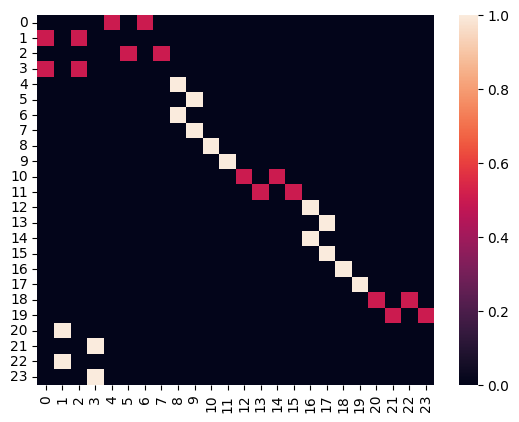

In [5]:
############################## Model matrix


######## Initialize parameters of the environment --- to include in CHMM class eventually when I make this more generalizable

#Initialize clone number vector
obs = np.arange(0,14,step=1)
noise_clones = 2 #Temp TO REMOVE 
n_clones = (np.ones(shape=obs.shape, dtype=np.int64))
n_clones_std = (np.ones(shape=obs.shape, dtype=np.int64))
n_clones_std[4:] = n_clones_std[4:]*2 #Attribute 2 clones to the noisy observations
n_clones[4:] = n_clones[4:]*noise_clones #Attribute 2 clones to the noisy observations

# Create the latent state labels, clones are next to each other 
latent_labels_std = []
for z in range(len(obs)):
    for clone in range(n_clones_std[z]):
        latent_labels_std.append(z)
latent_labels_std = np.array(latent_labels_std)      
        
# Example parse to find the appropriate clones
state_loc_std = np.hstack((np.array([0], dtype=n_clones_std.dtype), n_clones_std)).cumsum() # Inds of the first clone of each ensemble





# Create the latent state labels, clones are next to each other 
latent_labels = []
for z in range(len(obs)):
    for clone in range(n_clones[z]):
        latent_labels.append(z)
latent_labels = np.array(latent_labels)
# Create label matrix 
T_labels = [] ## Shouldn't be necessary in the end        
        
# Example parse to find the appropriate clones
state_loc = np.hstack((np.array([0], dtype=n_clones.dtype), n_clones)).cumsum() # Inds of the first clone of each ensemble
clone_slice = slice(state_loc[5],state_loc[5]+n_clones[5]) 
test1 = latent_labels[clone_slice] #example


def decoder(x,n_clones=n_clones,location_start=state_loc): # give slice coordinates in general coords for the clones mapped to emission x
    #will need extra work for more complex stimulus space than intergers
    clone_slice = slice(location_start[x],location_start[x]+n_clones[x])
    return clone_slice



#####33
k = 4 # Number of noise steps 
dim = 24


A = np.zeros(shape=(dim,dim))

# Signal nodes, manual picking
# 0 nodes
A[4,0] = 0.5
A[6,0] = 0.5

A[0,1] = 0.5
A[2,1] = 0.5

A[5,2] = 0.5
A[7,2] = 0.5

A[0,3] = 0.5
A[2,3] = 0.5 


# Noise nodes, sequentially pick MANUAL FOR THE END
progress = 0
for x in range(4,len(n_clones_std)-2): # need to advance on each step ? or jsut go on n clones and do it in 3 steps is etter
    progress += 1
    if progress%4 == 1 : 
        start = decoder(x,n_clones=n_clones_std,location_start=state_loc_std) 
        arrival = decoder(x+2,n_clones=n_clones_std,location_start=state_loc_std)
        A[arrival,start] = np.diag(np.full(2,1))
    elif progress%4 == 2:
        start = decoder(x,n_clones=n_clones_std,location_start=state_loc_std) 
        arrival = decoder(x+1,n_clones=n_clones_std,location_start=state_loc_std)
        A[arrival,start] = np.diag(np.full(2,1))
    elif progress%4 == 3:
        start = decoder(x,n_clones=n_clones_std,location_start=state_loc_std) 
        arrival = decoder(x+1,n_clones=n_clones_std,location_start=state_loc_std)
        A[arrival,start] = np.diag(np.full(2,1))
    elif progress%4 == 0:
        start = decoder(x,n_clones=n_clones_std,location_start=state_loc_std) 
        arrival_1 = decoder(x+1,n_clones=n_clones_std,location_start=state_loc_std)
        arrival_2 = decoder(x+2,n_clones=n_clones_std,location_start=state_loc_std)
        A[arrival_1,start] = np.diag(np.full(2,0.5))
        A[arrival_2,start] = np.diag(np.full(2,0.5))

# Tail end
x = 12
start = decoder(x,n_clones=n_clones_std,location_start=state_loc_std) 
A[1,start] = np.array([1,0])
A[3,start] = np.array([0,1])

x = 13
start = decoder(x,n_clones=n_clones_std,location_start=state_loc_std) 
A[1,start] = np.array([1,0])
A[3,start] = np.array([0,1])

sns.heatmap(A.T)



In [6]:
''' import code '''

import numpy as np
from chmm_actions_forward import CHMM, forwardE, datagen_structured_obs_room
import matplotlib.pyplot as plt
import igraph
from matplotlib import cm, colors
import os

100%|██████████| 2000/2000 [00:00<00:00, 71373.58it/s]

Average number of clones: 1.7142857142857142



  0%|          | 0/1000 [00:00<?, ?it/s]

100%|██████████| 1000/1000 [00:11<00:00, 90.21it/s, train_bps=0.552]


7.84213e-10


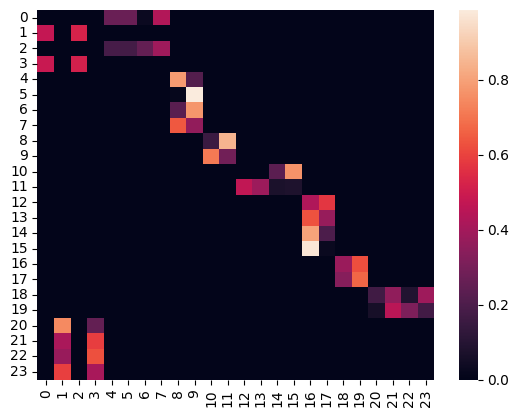

In [7]:
''' Train CHMM '''

## Sequence generation

def encoder(x,latent_labels=latent_labels): # converts poisitons to observation
        return latent_labels[x]



def encoder_old(x,k=k):
    if x in np.arange(0,4+(3*k-2)):
        return x
    else :
        return x - (3*k-2)

####################
## Training sequence
####################

# training sequence creation
position = 0
POS = np.arange(A.shape[0]) 
T = 2000 # sequence length

seq = [np.int64(0)]

for t in tqdm(range(T)):
    position = rd.choice(a = POS, p = A[:,position]) #Update position according to transition matrix
    seq.append(encoder(position,latent_labels=latent_labels_std)) #Append decoded sequence


## Train CHMM with Baum-Welch algorithm

# Train CHMM on random data
TIMESTEPS = T
OBS = 2
x = np.array(seq)
a = np.zeros(
    len(x), dtype=np.int64
)  # If there are actions in your domain replace this. If not, keep the vector of zeros.
n_clones = n_clones  # Number of clones specifies the capacity for each observation.

x_test = np.random.randint(
    OBS, size=(1000,)
)  # Test observations. Replace with your data.
a_test = np.zeros(1000, dtype=np.int64)

chmm = CHMM(n_clones=n_clones, pseudocount=1e-10, x=x, a=a)  # Initialize the model
progression = chmm.learn_em_T(x, a, n_iter=1000, term_early=False)  # Training

nll_per_prediction = chmm.bps(
    x_test, a_test
)  # Evaluate negative log-likelihood (base 2 log)
avg_nll = np.mean(nll_per_prediction)
avg_prediction_probability = 2 ** (-avg_nll)
print(avg_prediction_probability)


''' Paste result '''
# %matplotlib widget
plt.clf()
# sns.heatmap(chmm.T[0,:,:],annot=True,annot_kws={"size" : 5})
sns.heatmap(chmm.T[0,:,:])
plt.show()


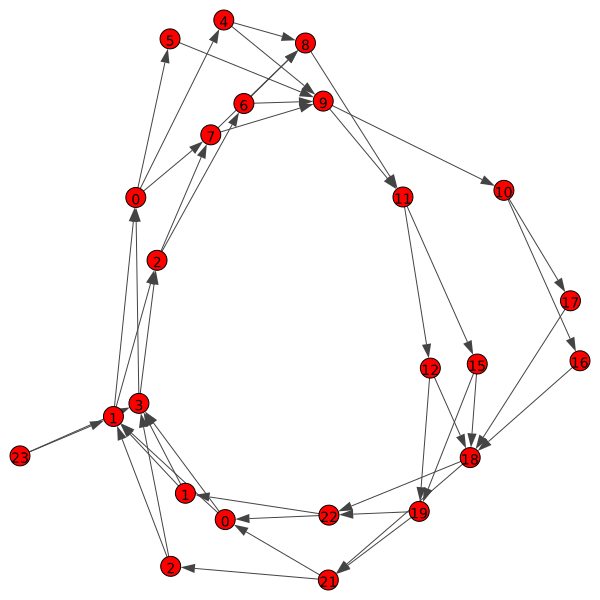

In [9]:
''' plot graph '''

def plot_graph(
    chmm, x, a, output_file, cmap=cm.Spectral, multiple_episodes=False, vertex_size=30
):
    states = chmm.decode(x, a)[1]

    v = np.unique(states)
    if multiple_episodes:
        T = chmm.C[:, v][:, :, v][:-1, 1:, 1:]
        v = v[1:]
    else:
        T = chmm.C[:, v][:, :, v]
    A = T.sum(0)
    A /= A.sum(1, keepdims=True)

    g = igraph.Graph.Adjacency((A > 0).tolist())
    node_labels = np.arange(x.max() + 1).repeat(n_clones)[v]
    if multiple_episodes:
        node_labels -= 1
    colors = [cmap(nl)[:3] for nl in node_labels / node_labels.max()]
    out = igraph.plot(
        g,
        output_file,
        layout=g.layout("kamada_kawai"),
        vertex_color=colors,
        vertex_label=v,
        vertex_size=vertex_size,
        margin=50,
    )

    return out

states = chmm.decode(x, a)[1]
v = np.unique(states)

g = igraph.Graph.Adjacency(((chmm.T[0,:,:] > 0.2)).tolist())
igraph.plot(g,vertex_label=v)

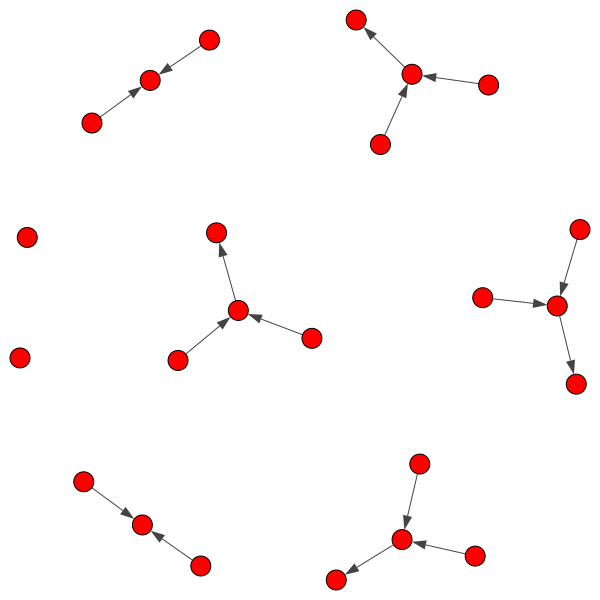

In [12]:
g = igraph.Graph.Adjacency(((A.T)).tolist())
igraph.plot(g)

<Axes: >

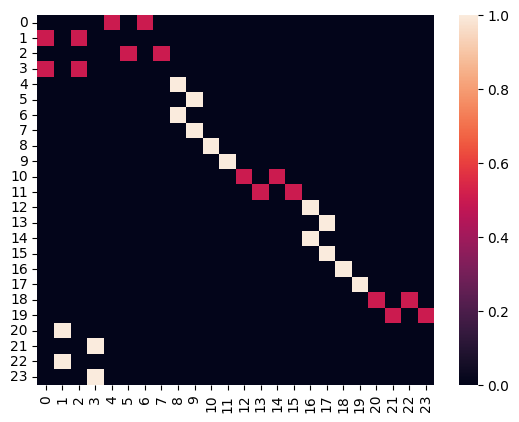

In [11]:
sns.heatmap(A.T)